In [ ]:
# 查看当前挂载的数据集目录, 该目录下的变更重启环境后会自动还原
# View dataset directory. 
# This directory will be recovered automatically after resetting environment. 
!ls /home/aistudio/data

In [ ]:
# 查看工作区文件，该目录下除data目录外的变更将会持久保存。请及时清理不必要的文件，避免加载过慢。
# View personal work directory. 
# All changes, except /data, under this directory will be kept even after reset. 
# Please clean unnecessary files in time to speed up environment loading. 
!ls /home/aistudio

In [ ]:
# 如果需要进行持久化安装, 需要使用持久化路径, 如下方代码示例:
# If a persistence installation is required, 
# you need to use the persistence path as the following: 
!mkdir /home/aistudio/external-libraries
!pip install beautifulsoup4

In [ ]:
# 同时添加如下代码, 这样每次环境(kernel)启动的时候只要运行下方代码即可: 
# Also add the following code, 
# so that every time the environment (kernel) starts, 
# just run the following code: 
import sys 
sys.path.append('/home/aistudio/external-libraries')

In [ ]:
!ls data

data32654


In [ ]:
!ls ./data/data32654

sample_submit.csv  used_car_testB.zip  used_car_train.zip


In [ ]:
unzip -oq /home/aistudio/data/data32654/used_car_testB.zip

In [ ]:
unzip -oq /home/aistudio/data/data32654/used_car_train.zip

In [ ]:
import pandas as pd
import zipfile

# 绝对路径，直接读取压缩包内文件，无需解压
train_zip_path = "/home/aistudio/data/data32654/used_car_train.zip"
test_zip_path = "/home/aistudio/data/data32654/used_car_testB.zip"

# 读取训练集
with zipfile.ZipFile(train_zip_path) as z:
    with z.open("used_car_train_20200313.csv") as f:
        train = pd.read_csv(f, sep=' ')

# 读取测试集
with zipfile.ZipFile(test_zip_path) as z:
    with z.open("used_car_testB_20200421.csv") as f:
        test = pd.read_csv(f, sep=' ')

print("✅ 训练集尺寸：", train.shape)
print("✅ 测试集尺寸：", test.shape)
train.head()

✅ 训练集尺寸： (150000, 31)
✅ 测试集尺寸： (50000, 30)


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


In [ ]:
# 查看数据集基础信息
print("====训练集基本信息====")
print(f"训练集：{train.shape}")
print(f"测试集：{test.shape}")
print("\n字段类型：")
print(train.info())

print("\n====描述性统计====")
print(train.describe())

print("\n====缺失值统计====")
print(train.isnull().sum())

====训练集基本信息====
训练集：(150000, 31)
测试集：(50000, 30)

字段类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              149999 non-null  float64
 4   brand              150000 non-null  int64  
 5   bodyType           145494 non-null  float64
 6   fuelType           141320 non-null  float64
 7   gearbox            144019 non-null  float64
 8   power              150000 non-null  int64  
 9   kilometer          150000 non-null  float64
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  int64  
 14  creatDate          150000 non-null  int64  


In [ ]:
# 统计缺失
missing = train.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print("缺失字段统计：")
print(missing)

# 查看notRepairedDamage的唯一值，看里面的'-'
print("\nnotRepairedDamage唯一取值：")
print(train['notRepairedDamage'].unique())

缺失字段统计：
fuelType    8680
gearbox     5981
bodyType    4506
model          1
dtype: int64

notRepairedDamage唯一取值：
['0.0' '-' '1.0']


In [ ]:
import numpy as np

df_train = train.copy()

# 1. 处理notRepairedDamage：把'-'替换成np.nan，再转为数值
df_train['notRepairedDamage'] = df_train['notRepairedDamage'].replace('-', np.nan)
df_train['notRepairedDamage'] = df_train['notRepairedDamage'].astype(float)

# 2. 类别缺失用众数填充
df_train['fuelType'].fillna(df_train['fuelType'].mode()[0], inplace=True)
df_train['gearbox'].fillna(df_train['gearbox'].mode()[0], inplace=True)
df_train['bodyType'].fillna(df_train['bodyType'].mode()[0], inplace=True)
df_train['model'].fillna(df_train['model'].mode()[0], inplace=True)
df_train['notRepairedDamage'].fillna(df_train['notRepairedDamage'].mode()[0], inplace=True)

# 3. 构造车龄特征
df_train['regDate'] = df_train['regDate'].astype(str)
df_train['creatDate'] = df_train['creatDate'].astype(str)
df_train['reg_year'] = df_train['regDate'].str[:4].astype(int)
df_train['create_year'] = df_train['creatDate'].str[:4].astype(int)
df_train['car_age'] = df_train['create_year'] - df_train['reg_year']

# 4. 过滤异常：车龄不能负数，价格大于0
df_train = df_train[(df_train['car_age'] >= 0)]
df_train = df_train[df_train['price'] > 0]

print("清洗后训练集shape：", df_train.shape)
print("剩余缺失总量：", df_train.isnull().sum().sum())

清洗后训练集shape： (150000, 34)
剩余缺失总量： 0


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/font_manager.py:1331: UserWarning: findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


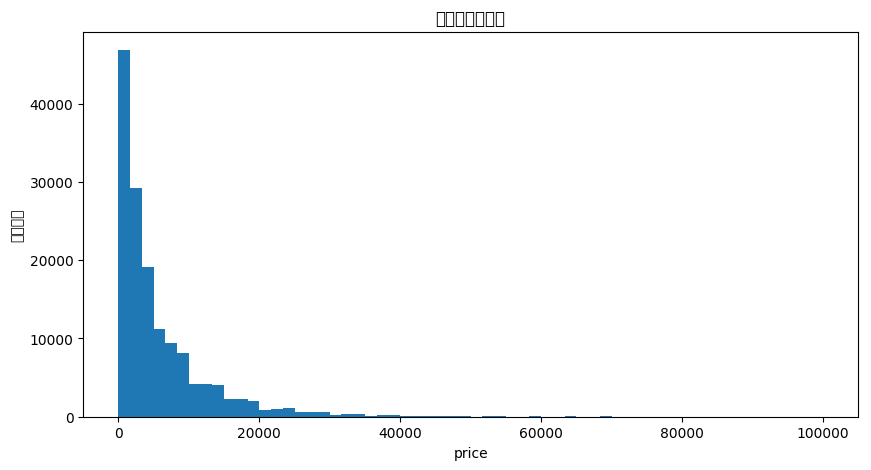

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,5))
plt.hist(df_train['price'], bins=60)
plt.title('二手车价格分布')
plt.xlabel('price')
plt.ylabel('样本数量')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# 抽取20%样本，快速训练
df_sample = df_train.sample(frac=0.2, random_state=42)

drop_cols = ['SaleID', 'name', 'regDate', 'creatDate']
X = df_sample.drop(drop_cols + ['price'], axis=1)
y_raw = df_sample['price']
y = np.log1p(y_raw)

# 划分训练、验证集
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 减少树数量，进一步提速
lgb_reg = lgb.LGBMRegressor(
    random_state=42,
    n_estimators=50,
    learning_rate=0.2,
    n_jobs=-1,
    verbose=-1
)
lgb_reg.fit(X_train, y_train) 

# 在验证集预测评估
y_pred_log = lgb_reg.predict(X_val)
y_pred = np.expm1(y_pred_log)
y_val_real = np.expm1(y_val)
mae = mean_absolute_error(y_val_real, y_pred)
print(f"✅采样版本验证集MAE: {mae:.2f}")

✅采样版本验证集MAE: 792.25


In [25]:
df_test = test.copy()

# 处理notRepairedDamage脏数据，和训练集逻辑保持一致
df_test['notRepairedDamage'] = df_test['notRepairedDamage'].replace('-', np.nan)
df_test['notRepairedDamage'] = df_test['notRepairedDamage'].astype(float)

# 填充缺失，使用完整df_train的众数，防止数据泄露
df_test['fuelType'].fillna(df_train['fuelType'].mode()[0], inplace=True)
df_test['gearbox'].fillna(df_train['gearbox'].mode()[0], inplace=True)
df_test['bodyType'].fillna(df_train['bodyType'].mode()[0], inplace=True)
df_test['model'].fillna(df_train['model'].mode()[0], inplace=True)
df_test['notRepairedDamage'].fillna(df_train['notRepairedDamage'].mode()[0], inplace=True)

# 构造车龄特征
df_test['regDate'] = df_test['regDate'].astype(str)
df_test['creatDate'] = df_test['creatDate'].astype(int).astype(str)
df_test['reg_year'] = df_test['regDate'].str[:4].astype(int)
df_test['create_year'] = df_test['creatDate'].str[:4].astype(int)
df_test['car_age'] = df_test['create_year'] - df_test['reg_year']

drop_cols = ['SaleID', 'name', 'regDate', 'creatDate']
X_test = df_test.drop(drop_cols, axis=1)

# 预测
y_test_log = lgb_reg.predict(X_test)
y_test_pred = np.expm1(y_test_log)

# 生成提交文件
sub = df_test[['SaleID']].copy()
sub['price'] = y_test_pred
sub.to_csv('submission.csv', index=False)
print("✅ 预测完成，submission.csv 文件生成成功！")

✅ 预测完成，submission.csv 文件生成成功！


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/font_manager.py:1331: UserWarning: findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


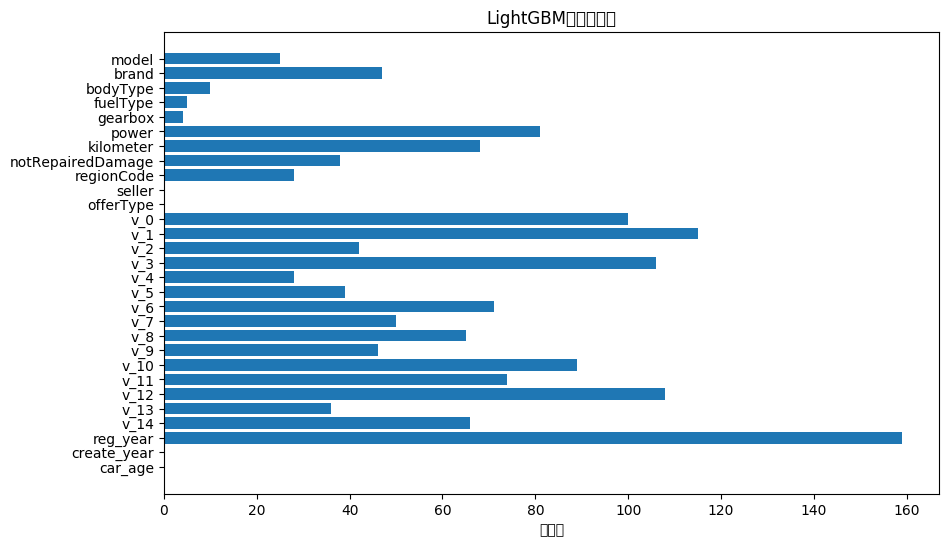

In [27]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] #解决中文乱码
plt.rcParams['axes.unicode_minus'] = False

feature_importance = lgb_reg.feature_importances_
feature_name = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_name, feature_importance)
plt.gca().invert_yaxis()
plt.title('LightGBM特征重要性')
plt.xlabel('重要性')
plt.show()

请点击[此处](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576)查看本环境基本用法.  <br>
Please click [here ](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576) for more detailed instructions. 